# 4. Mushroom foraging

The [mushroom dataset](https://www.kaggle.com/datasets/dhinaharp/mushroom-dataset) contains data about approximately 60000 mushrooms, and your task is to classify them as either edible or poisonous. You can read about the features [here](https://www.kaggle.com/datasets/uciml/mushroom-classification) and import the data using:

In [110]:
import pandas as pd
pd.set_option('display.max_columns', 1000)
df = pd.read_csv('secondary_data.csv', delimiter = ';')
df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,17.09,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,18.19,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,17.74,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,15.98,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,17.20,s,y,w,u,w,t,p,NaN,d,w


It's up to you how you approach this data, but at a minimum, your analysis should include:

* Informed **data preparation**.
* 2 different classification models, one of which must be **logistic regression**.
* A discussion of which **performance metric** is most relevant for the evaluation of your models.
* 2 different **validation methodologies** used to tune hyperparameters.
* **Confusion matrices** for your models, and associated comments.

### Data analysis/cleansing

In [111]:
print(f"Nulls\n{df.isnull().sum()}")

data = df.drop(['stem-root', 'stem-surface', 'veil-type', 'veil-color', 'spore-print-color'], axis='columns')

data = data.drop_duplicates()

# these ones had an unknown = blank category in teh dataset
data['gill-attachment'] = data['gill-attachment'].fillna('unknown')
data['ring-type'] = data['ring-type'].fillna('unknown')

for column in ['cap-surface', 'gill-spacing']:
    data[column] = data[column].fillna(data[column].mode()[0])

print("\nNum poisonous/edible")
print(f"poisonous - {(data['class'] == 'p').sum()}")
print(f"edible - {(data['class'] == 'e').sum()}")


Nulls
class                       0
cap-diameter                0
cap-shape                   0
cap-surface             14120
cap-color                   0
does-bruise-or-bleed        0
gill-attachment          9884
gill-spacing            25063
gill-color                  0
stem-height                 0
stem-width                  0
stem-root               51538
stem-surface            38124
stem-color                  0
veil-type               57892
veil-color              53656
has-ring                    0
ring-type                2471
spore-print-color       54715
habitat                     0
season                      0
dtype: int64

Num poisonous/edible
poisonous - 33742
edible - 27181


### Encoding

In [112]:
data['class'] = data['class'].map({'e': 1, 'p': 0})
data['does-bruise-or-bleed'] = data['does-bruise-or-bleed'].map({'t': 1, 'f' : 0})
data['has-ring'] = data['has-ring'].map({'t': 1, 'f' : 0})

categories = [
    'cap-shape', 'cap-surface', 'cap-color', 'gill-attachment', 
    'gill-spacing', 'gill-color', 'stem-color',
    'ring-type', 'habitat', 'season'
]

data = pd.get_dummies(data, columns=categories, drop_first=True)

### Scaling

In [113]:
from sklearn.preprocessing import StandardScaler

numericals = ['cap-diameter', 'stem-height', 'stem-width']
scaler = StandardScaler()
data[numericals] = scaler.fit_transform(data[numericals])

### Analyzing correlation

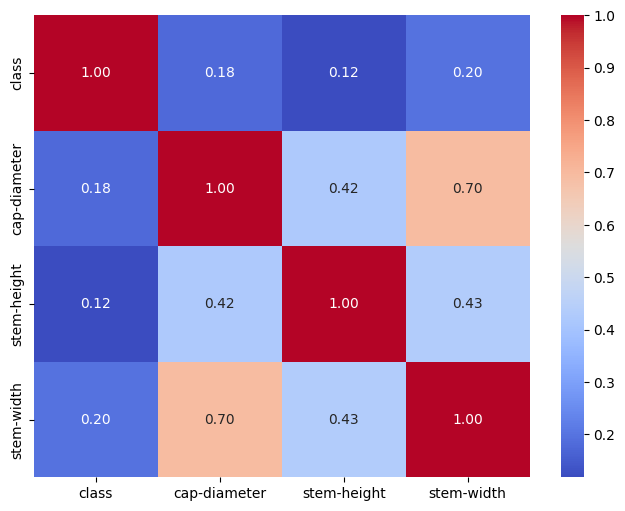

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_columns = ['class', 'cap-diameter', 'stem-height', 'stem-width']
corr_matrix = data[numerical_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt='.2f')
plt.show()

### Splitting data

In [ ]:
from sklearn.model_selection import train_test_split

features = data.drop('class', axis = 1)
label = data['class']

X_train_full, X_test, y_train_full, y_test = train_test_split(features, label, test_size = 0.2, random_state = 42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size = 0.2, random_state = 42)

X_train.head()

,cap-diameter,does-bruise-or-bleed,stem-height,stem-width,has-ring,cap-shape_c,cap-shape_f,cap-shape_o,cap-shape_p,cap-shape_s,cap-shape_x,cap-surface_e,cap-surface_g,cap-surface_h,cap-surface_i,cap-surface_k,cap-surface_l,cap-surface_s,cap-surface_t,cap-surface_w,cap-surface_y,cap-color_e,cap-color_g,cap-color_k,cap-color_l,cap-color_n,cap-color_o,cap-color_p,cap-color_r,cap-color_u,cap-color_w,cap-color_y,gill-attachment_d,gill-attachment_e,gill-attachment_f,gill-attachment_p,gill-attachment_s,gill-attachment_unknown,gill-attachment_x,gill-spacing_d,gill-spacing_f,gill-color_e,gill-color_f,gill-color_g,gill-color_k,gill-color_n,gill-color_o,gill-color_p,gill-color_r,gill-color_u,gill-color_w,gill-color_y,stem-color_e,stem-color_f,stem-color_g,stem-color_k,stem-color_l,stem-color_n,stem-color_o,stem-color_p,stem-color_r,stem-color_u,stem-color_w,stem-color_y,ring-type_f,ring-type_g,ring-type_l,ring-type_m,ring-type_p,ring-type_r,ring-type_unknown,ring-type_z,habitat_g,habitat_h,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w,season_s,season_u,season_w
50673,-0.717858,0,-0.421946,-0.138429,0,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
10383,-0.626749,0,-0.680972,-0.872207,0,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
48655,1.971767,0,2.302299,4.969106,0,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
19906,-0.167405,0,0.256882,-0.401632,0,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
57166,0.787345,0,-0.552948,0.811694,1,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


### Performance metrics
These models are intended to predict whether or not the mushrooms in the dataset are edible. Considering the worst case scenario in which someone eats a mushroom that was incorrectly predicted to be edible (edible = 1/true, poisonous = 0/false), we want to focus on avoiding false positives, which means focusing on precision.

### Hold out validation + logistic regressor

In [116]:
from sklearn.metrics import precision_score, recall_score, f1_score

def print_scores(type, predictions, actual):
    print(f"{type}")
    print(f"precision - {precision_score(actual, predictions)}")
    print(f"recall - {recall_score(actual, predictions)}")
    print(f"f1 - {f1_score(actual, predictions)}\n")

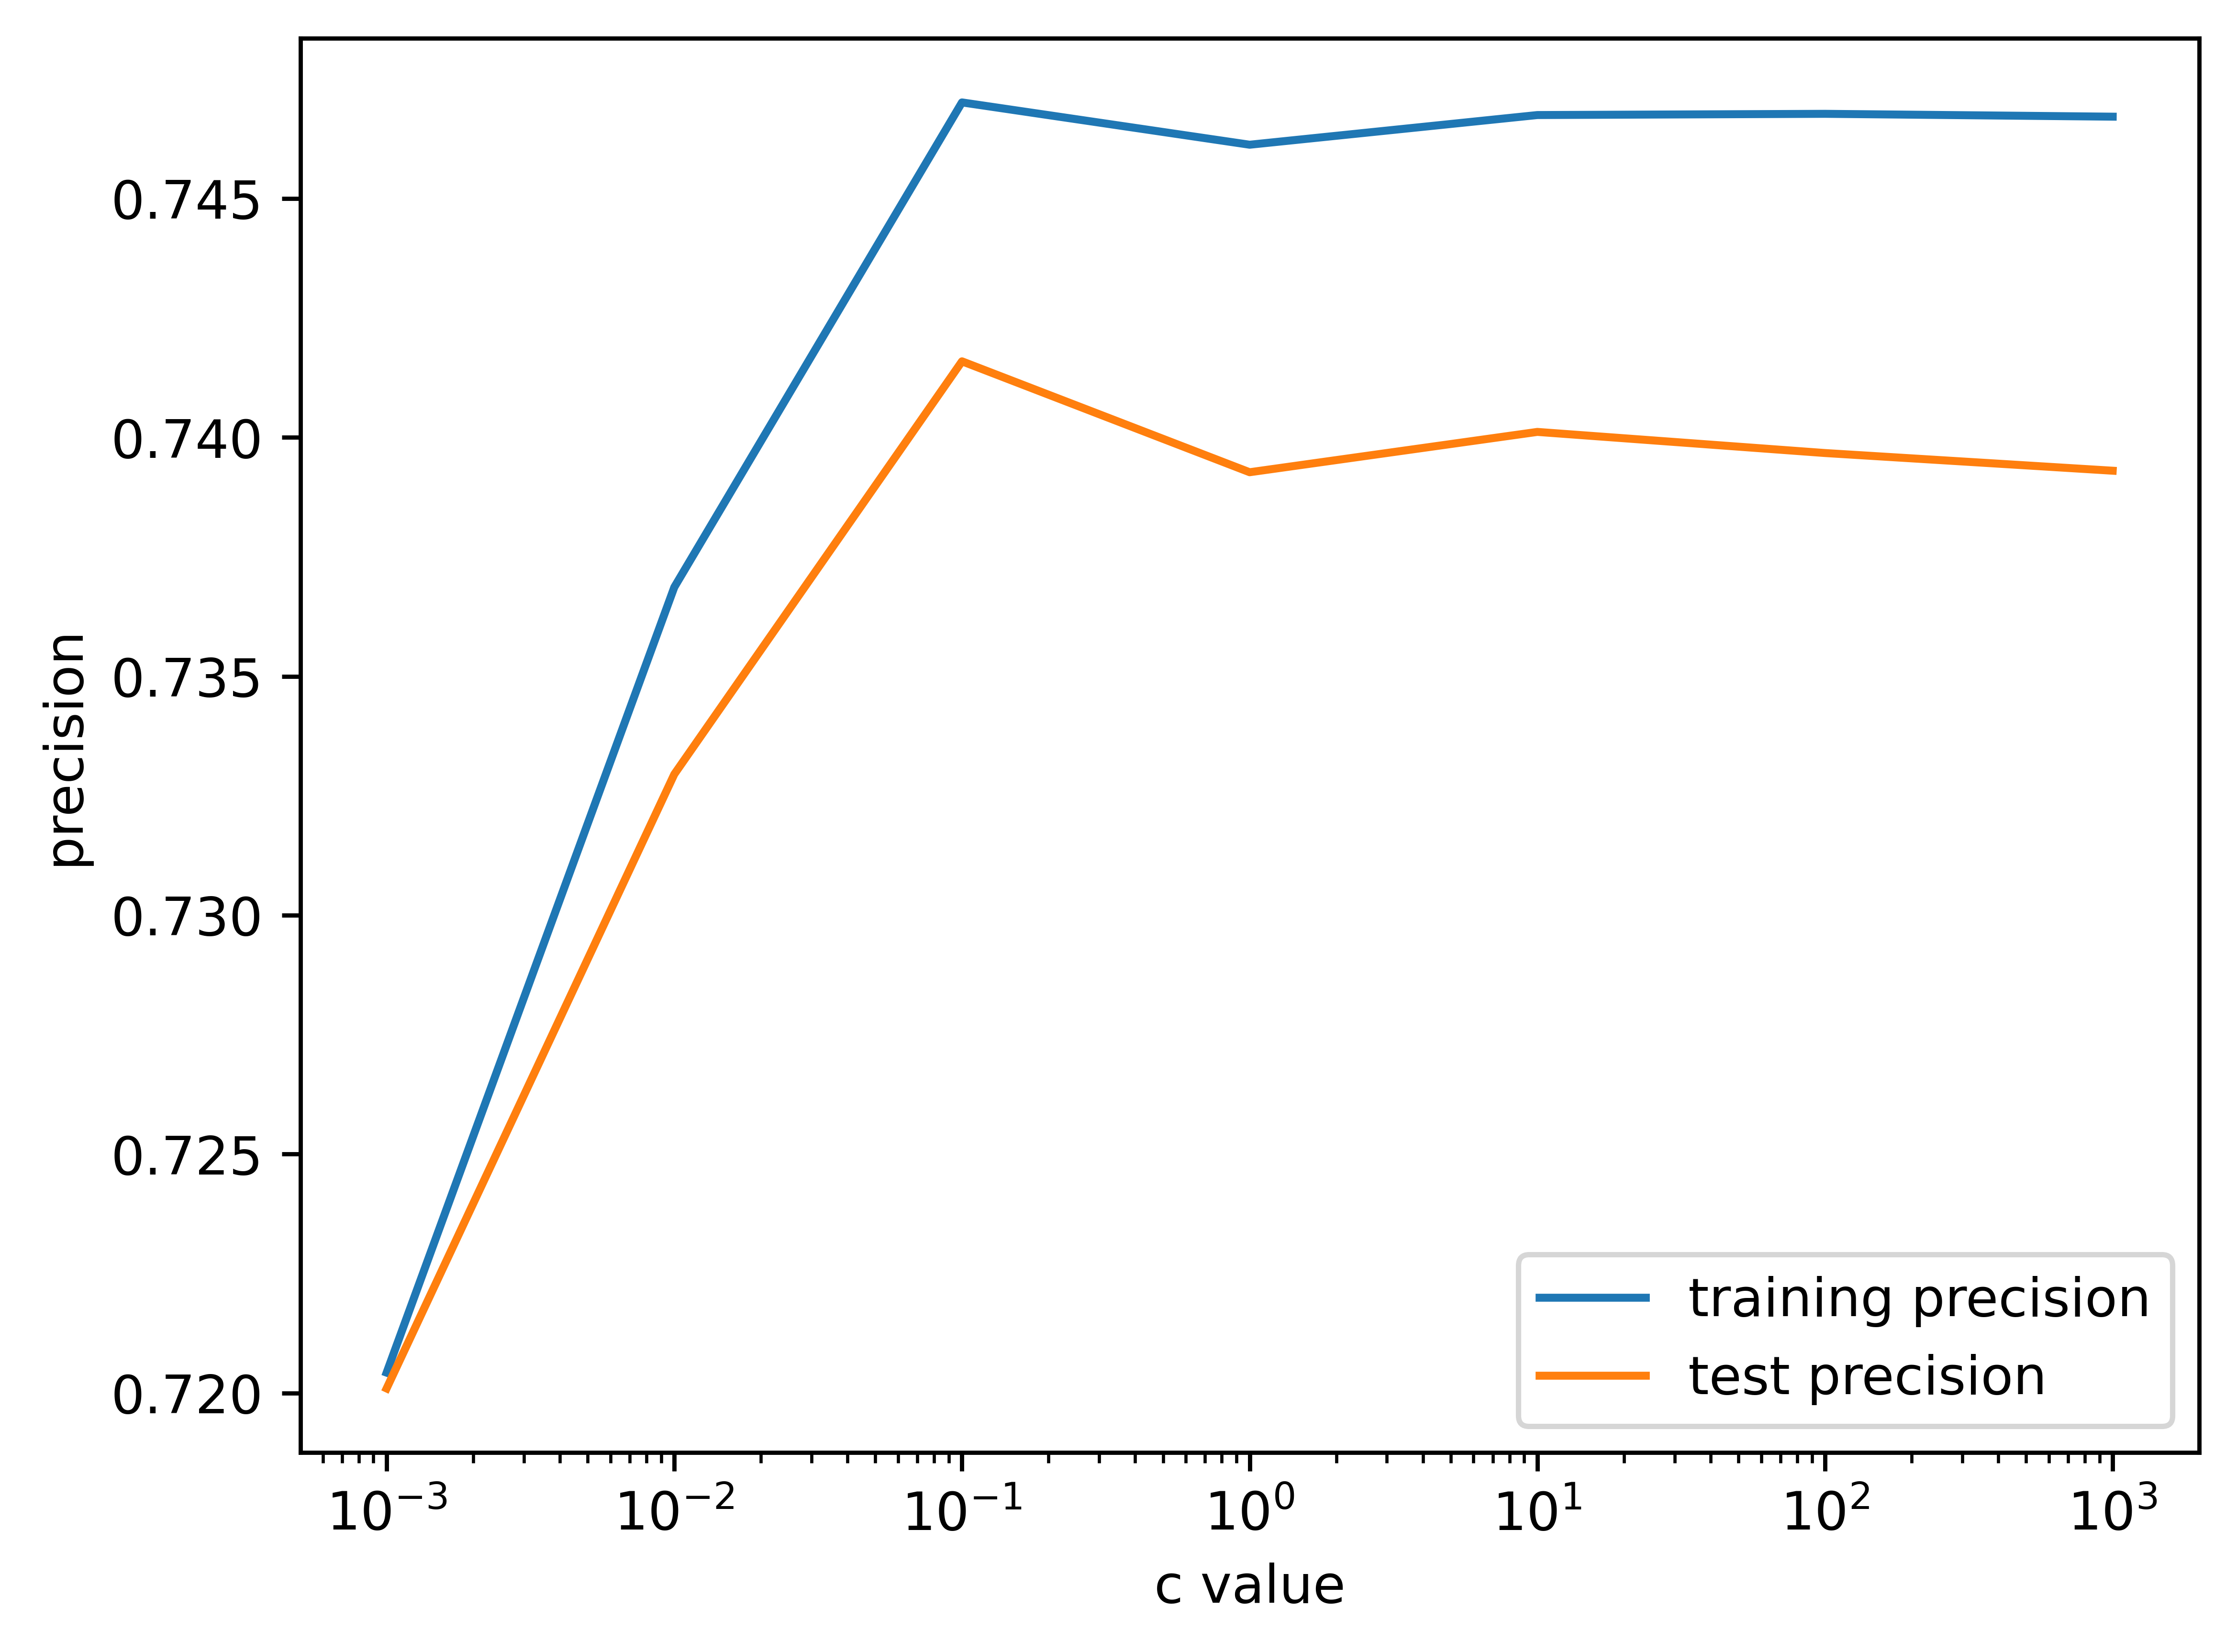

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

c_values = [0.001,0.01,0.1,1,10,100,1000]
training_precision = []
test_precision = []

for c in c_values:
    model = LogisticRegression(max_iter = 1000, random_state = 42, C=c)
    model.fit(X_train_full, y_train_full)
    train_results = model.predict(X_train_full)
    test_results = model.predict(X_test)

    train_precision = precision_score(y_train_full, train_results)
    testing_precision = precision_score(y_test, test_results)
    training_precision.append(train_precision)
    test_precision.append(testing_precision)


plt.figure(dpi = 800)
plt.plot(c_values, training_precision, label = "training precision")
plt.plot(c_values, test_precision, label = "test precision")
plt.ylabel("precision")
plt.xlabel("c value")
plt.xscale('log')
plt.legend()
plt.show()


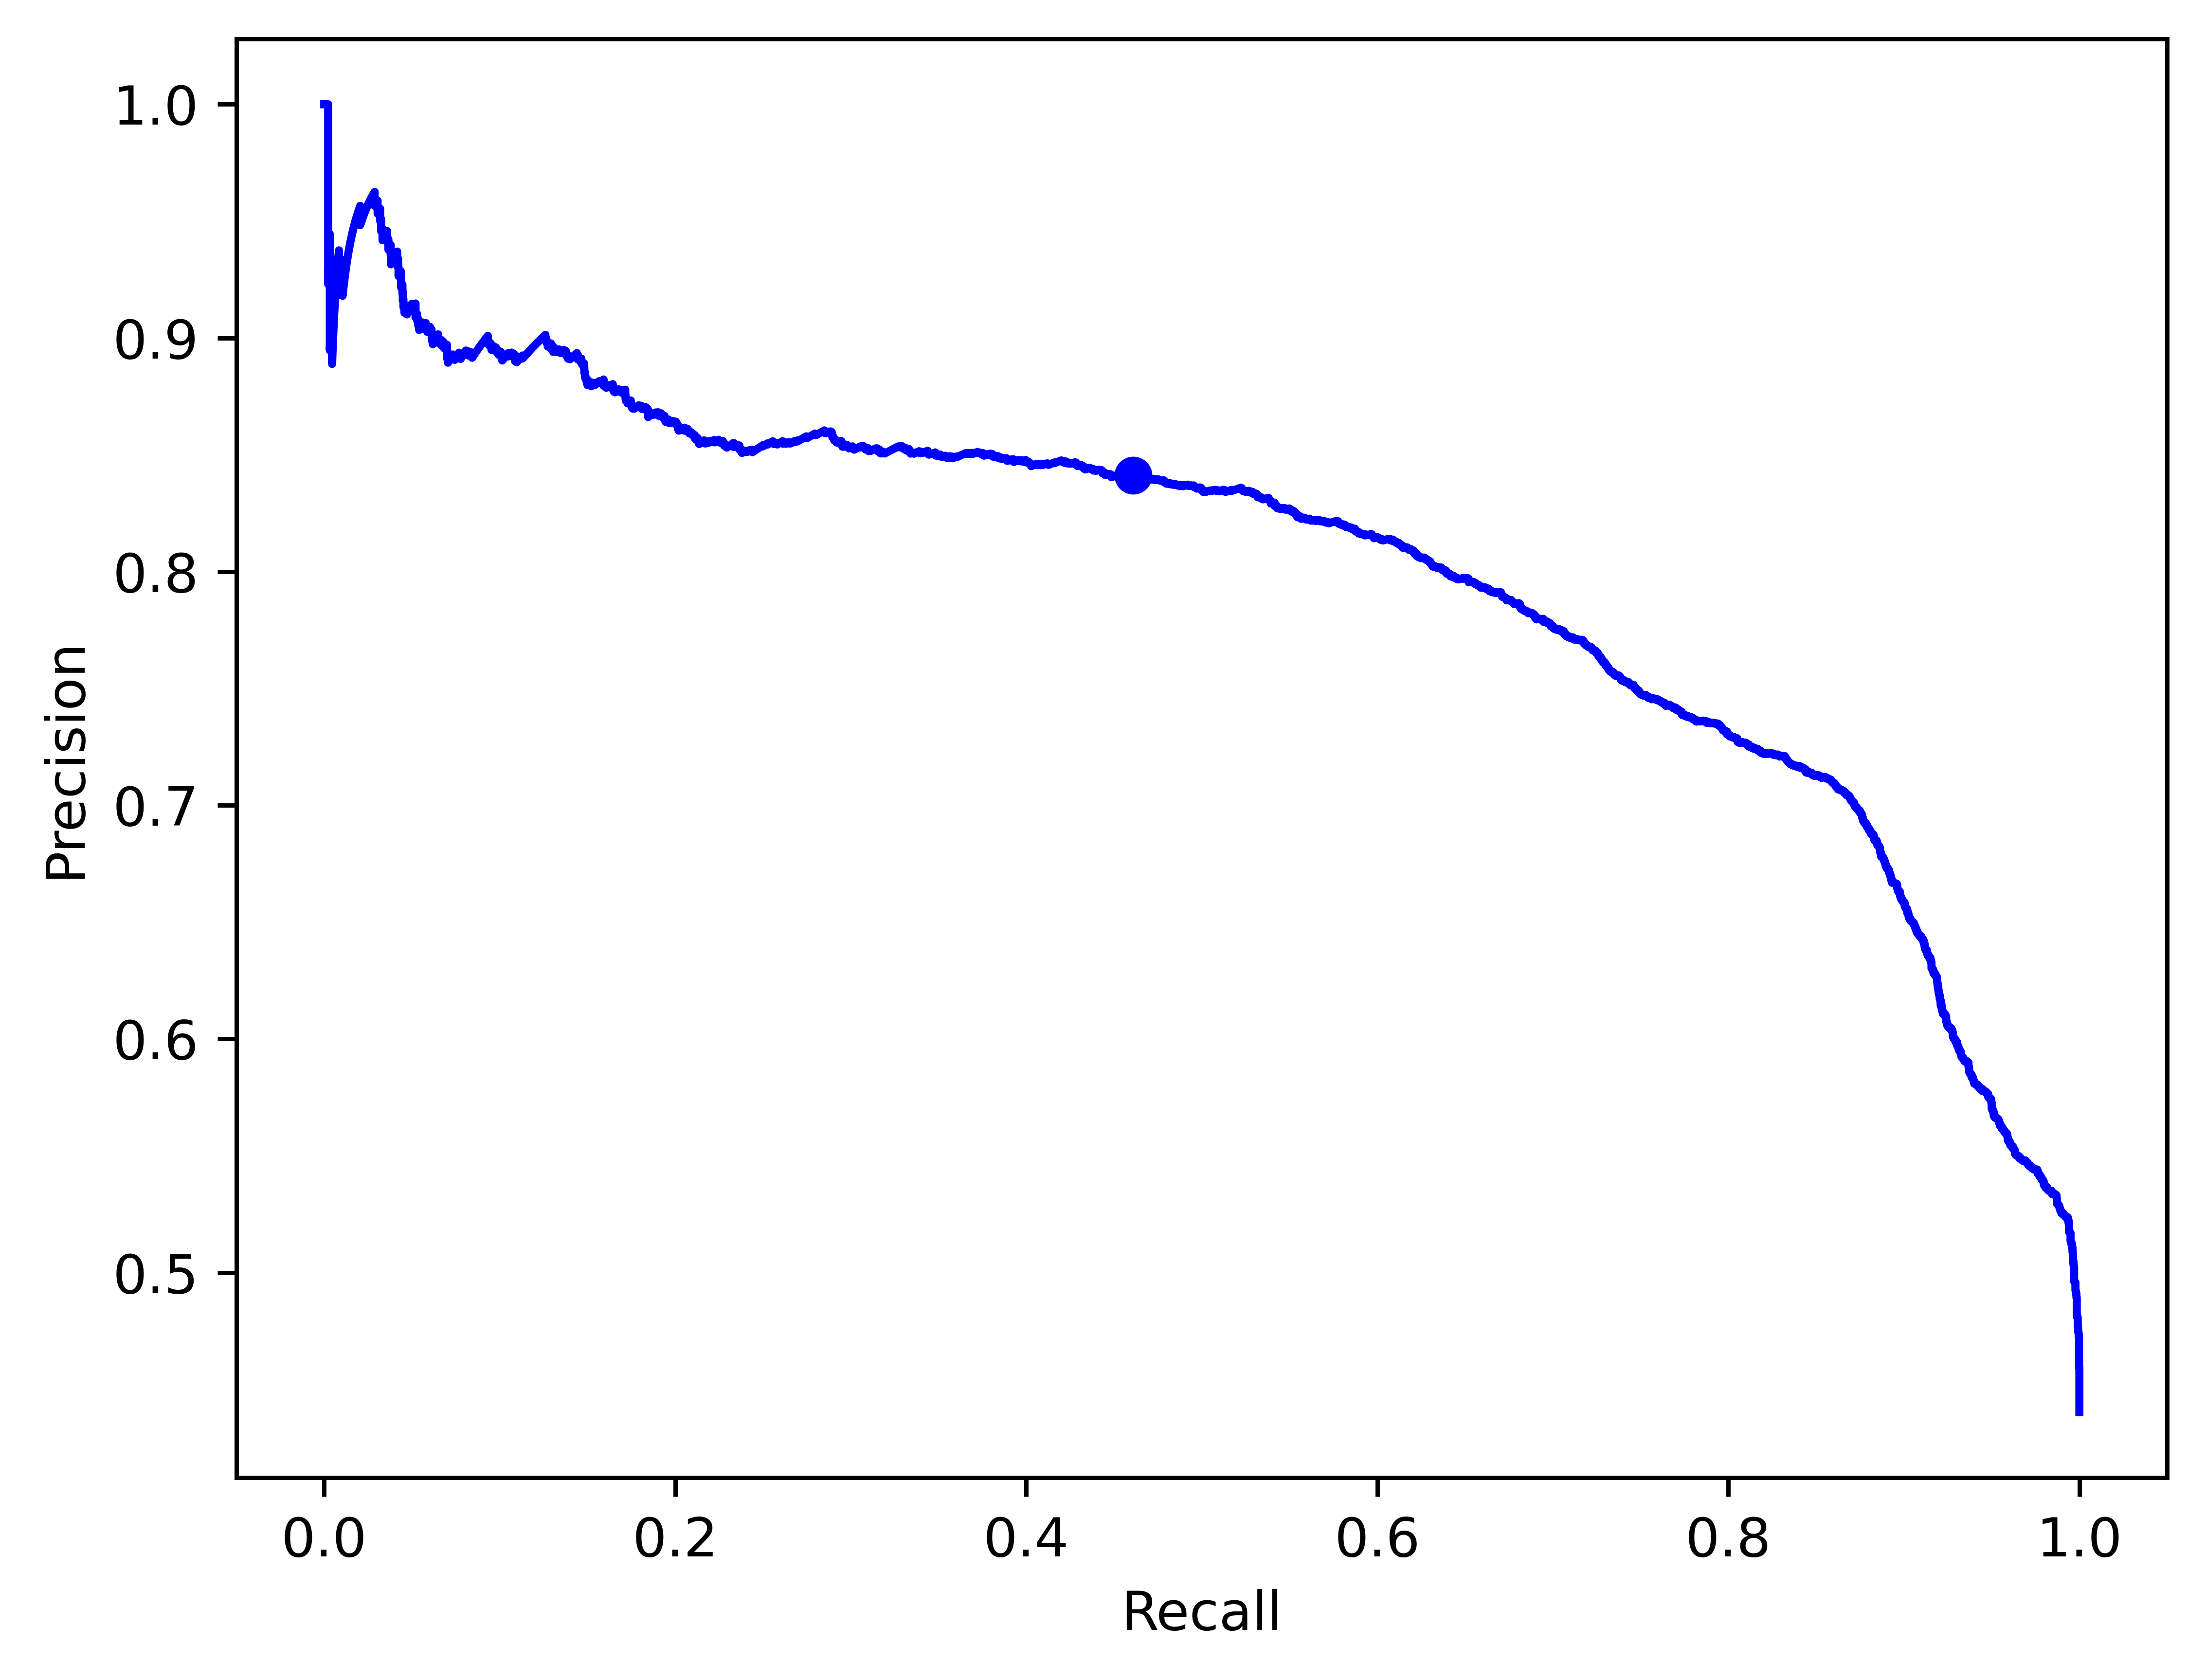

AUC is 0.8007642278133602
recall - 0.46095060577819197
precision - 0.841156462585034


In [131]:
# seems like 0.1 is the best value for c..
from sklearn.metrics import precision_recall_curve, auc

model = LogisticRegression(max_iter = 1000, random_state = 42, C=0.1)
model.fit(X_train_full, y_train_full)
predictions = model.predict(X_test)

adjusted = model.predict_proba(X_test)[:, 1]
threshold = 0.7
test_predictions = (adjusted >= threshold).astype(int)

prec,rec,thresholds = precision_recall_curve(y_test, adjusted)

plt.figure(dpi=800)
plt.plot(rec, prec,'b')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.plot(recall_score(y_test, test_predictions),
         precision_score(y_test, test_predictions),'bo')
plt.show()
print(f"AUC is {auc(rec,prec)}")
print(f"recall - {recall_score(y_test, test_predictions)}")
print(f"precision - {precision_score(y_test, test_predictions)}")

Precision was the priority, so adjusting the threshold to 0.7 from the default 0.5 means the model needs to be more certain that something's edible in order to classify it as positive

In [133]:
from sklearn.metrics import confusion_matrix

matrix = confusion_matrix(y_test, test_predictions)
print(matrix)

[[6353  467]
 [2892 2473]]


### KFold CV + random forest classifier

best parameters - {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 10}
testing
precision - 0.9656881433473122
recall - 0.9442684063373719
f1 - 0.9548581660540948

testing adjusted for precision
precision - 0.9879595785852505
recall - 0.8564771668219944
f1 - 0.9175319488817891



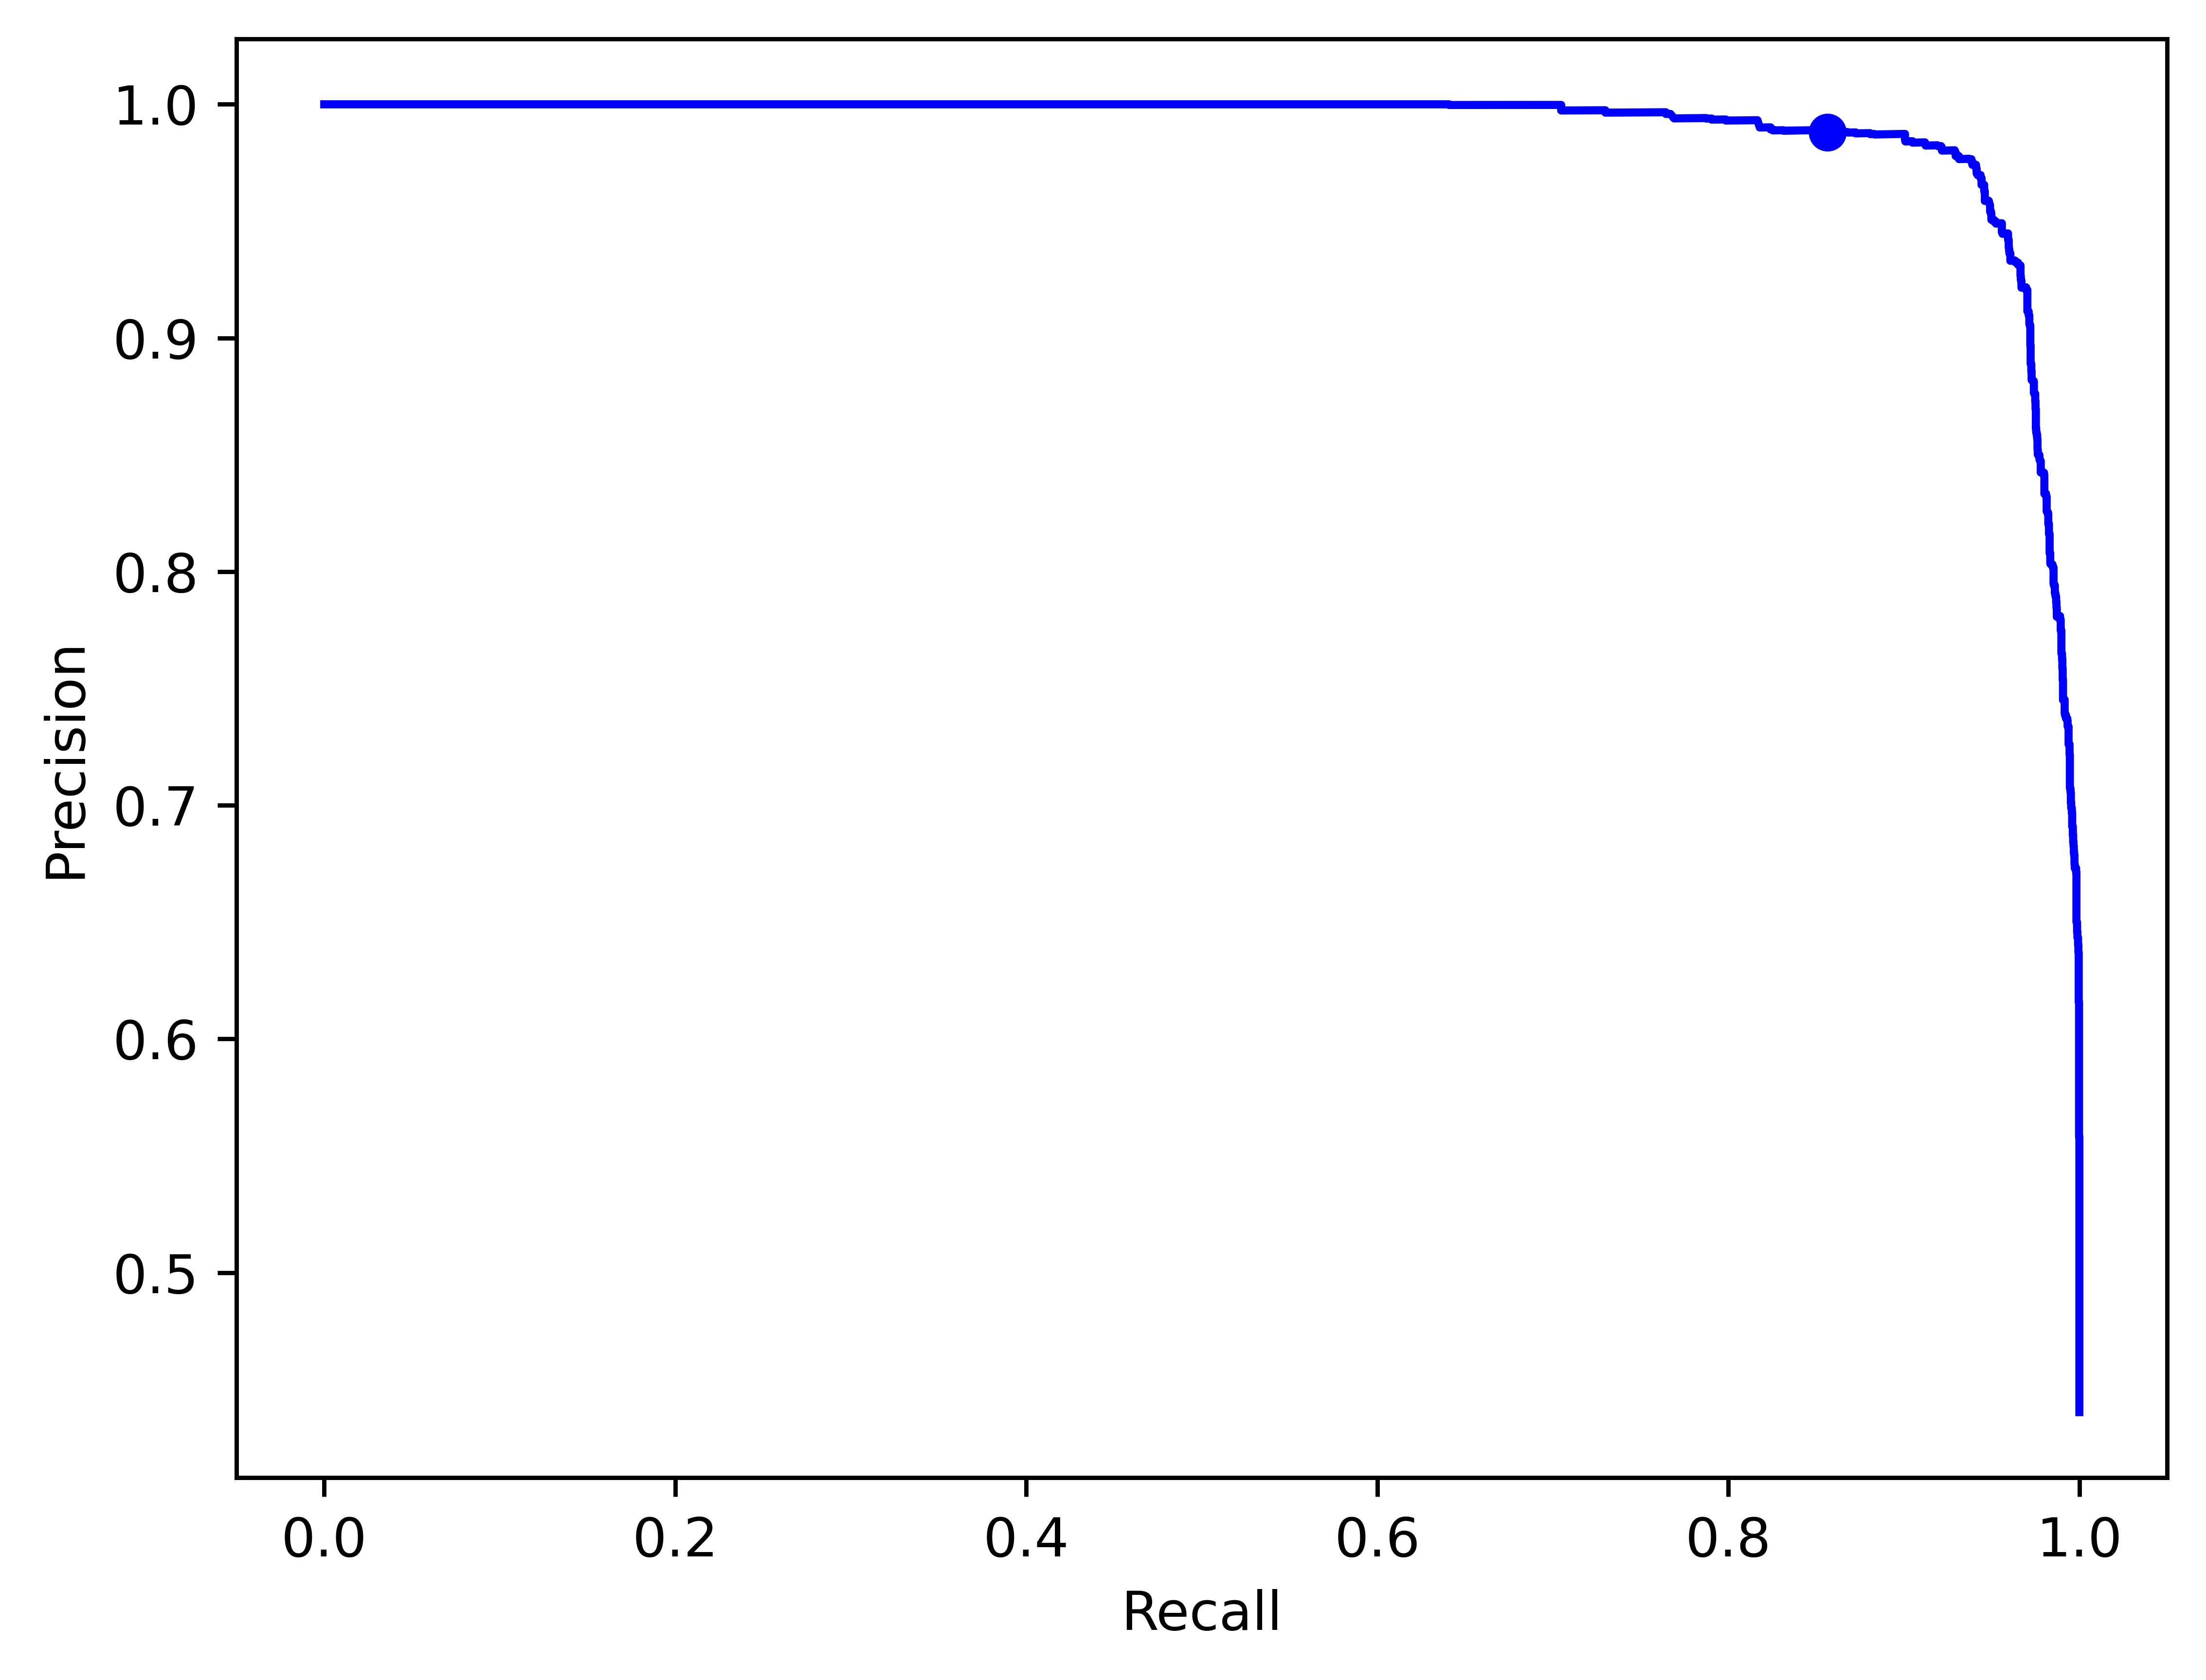

AUC is 0.989886366368647


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state = 42)
grid_values = {
    'n_estimators': [5, 10],
    'max_depth': [1, 10],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 5]
}

skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
grid_search = GridSearchCV(estimator = model, param_grid = grid_values, cv = skf, n_jobs = -1, scoring = 'precision')

grid_search.fit(X_train, y_train) # fit on cv folds
print(f"best parameters - {grid_search.best_params_}")

model = grid_search.best_estimator_
model.fit(X_train, y_train)

test_predictions = model.predict(X_test)
print_scores("testing", test_predictions, y_test)

adjusted = model.predict_proba(X_test)[:, 1]
threshold = 0.6
test_predictions = (adjusted >= threshold).astype(int)
print_scores("testing adjusted for precision", test_predictions, y_test)

prec,rec,thresholds = precision_recall_curve(y_test,adjusted)

plt.figure(dpi = 800)
plt.plot(rec, prec, 'b')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.plot(recall_score(y_test, test_predictions),
         precision_score(y_test, test_predictions),'bo')
plt.show()
print(f"AUC is {auc(rec,prec)}")

In [127]:
matrix = confusion_matrix(y_test, test_predictions)
print(matrix)

[[6764   56]
 [ 770 4595]]


In [90]:
feature_importances = pd.Series(model.feature_importances_, index=X_train.columns)
feature_importances.sort_values(ascending=False)

stem-width           0.156983
cap-diameter         0.082604
gill-attachment_p    0.076338
stem-height          0.070684
stem-color_w         0.060948
                       ...   
stem-color_l         0.000000
stem-color_k         0.000000
gill-color_o         0.000000
stem-color_f         0.000000
cap-surface_i        0.000000
Length: 82, dtype: float64